In [1]:
# using Pkg
# Pkg.activate("/home/jek354/research/ML-signproblem")
# Pkg.update()

using Lattices
using LinearAlgebra
using Combinatorics
using SparseArrays
using Plots
import Graphs
using LaTeXStrings
using Statistics
using Random
using Zygote
using Optimization, OptimizationOptimisers
using JSON
using OptimizationOptimJL
using JLD2
using ExponentialUtilities


include("ed_objects.jl")
include("ed_functions.jl")
include("ed_optimization.jl")
include("utility_functions.jl")

merge_jld2_folder

In [30]:
folder = "data/N=(3, 3)_3x2"
# folder="data/tmp"

e_metadata = load_saved_dict(joinpath(folder, "meta_data_and_E.jld2"))
U_values = e_metadata["meta_data"]["U_values"]
dim = [parse(Int, x) for x in split(e_metadata["meta_data"]["sites"], "x")]
shared_data = load_saved_dict(joinpath(folder, "unitary_map_energy_symmetry=false_N=(3, 3)_shared.jld2"))
coefficient_data = []
interaction_data = []
loss = []
initial_loss = [] 
for i = 6:61#2:61
    dic = load_saved_dict(joinpath(folder, "unitary_map_energy_symmetry=false_N=(3, 3)_u_$i.jld2"))
    push!(coefficient_data, dic["coefficients"][2])
    push!(interaction_data, U_values[i])
    push!(loss, dic["metrics"]["loss"][2])
    push!(initial_loss, dic["metrics"]["loss"][1])
end

┌ Warning: some parameters could not be resolved for type OptimizationFunction{true,AutoZygote,JLD2.ReconstructedMutable{Symbol("#f_adjoint#154{Bool,Vector{ComplexF64},Vector{ComplexF64},Int64,Nothing,Nothing,Vector{Any},Vector{Int64},Vector{Float64},Vector{Int64},Vector{Int64}}"), (:use_symmetry, :antihermitian, :state1, :state2, :dim, :parity, :parameter_mapping, :ops, :param_index_map, :signs, :cols, :rows), Tuple{Any, Bool, Any, Any, Int64, Nothing, Nothing, Vararg{Any, 5}}},Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,typeof(SciMLBase.DEFAULT_OBSERVED_NO_TIME),Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing}; reading as OptimizationFunction{true, AutoZygote, JLD2.ReconstructedMutable{Symbol("#f_adjoint#154{Bool,Vector{ComplexF64},Vector{ComplexF64},Int64,Nothing,Nothing,Vector{Any},Vector{Int64},Vector{Float64},Vector{Int64},Vector{Int64}}"), (:use_symmetry, :antihermitian, :state1, :state2,

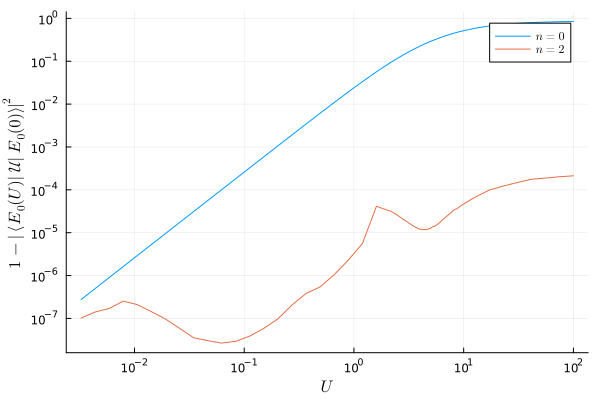

In [31]:
plot(yscale=:log10, xscale=:log10, ylabel=L"1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2", xlabel=L"U", yticks=10.0 .^(-10:0), xticks=10.0 .^(-3:3))
plot!(interaction_data, initial_loss, label=L"n=0")
plot!(interaction_data, loss, label=L"n=2")

In [100]:
load_saved_dict(joinpath(folder, "unitary_map_energy_symmetry=false_N=(3, 3)_u_25.jld2"))["metrics"]

Dict{String, Vector{Any}} with 3 entries:
  "other"    => [retcode: Failure…
  "loss_std" => [0.0]
  "loss"     => [0.0192576, 2.72429e-5]

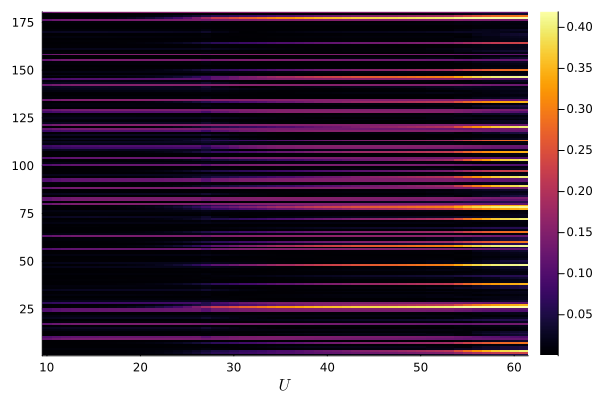

In [29]:
heatmap(10:61, 1:180, abs.(reduce(hcat, coefficient_data)), xlabel=L"U")

In [18]:
coefficient_data

40-element Vector{Any}:
 [-7.522930684934638e-5, -0.011666618987993616, -0.008751728388006124, 0.005943535032494837, 0.000956331453175582, -0.0007606322943024365, 0.011818704698277357, -0.00034796846353665187, 0.1408647749831782, -0.12246363244283331  …  -0.005043870932927792, 0.0008164496603870926, -6.542875220009176e-5, 0.0003216375102807018, -0.005352608067133929, 0.14089311826215817, 0.04700969019930142, 0.011756419346316964, -0.00025724641784337815, 0.15271130707259611]
 [-0.00013097121002077732, -0.015657620250138227, -0.011813531409456898, 0.005876267797850288, 0.0011843416852573801, -0.0007703507200394049, 0.015881807156396623, -0.0003533517623707998, 0.14091185587915991, -0.1237952650106066  …  -0.004893728456338687, 0.00082789316434909, -6.467961889584501e-5, 0.0003237954056183885, -0.00520818804950497, 0.141629973021999, 0.06266804287183099, 0.015734161691792058, -0.0002603022424704963, 0.1534863684970753]
 [-0.00023184889629739713, -0.0209257314435497, -0.015924716002372757

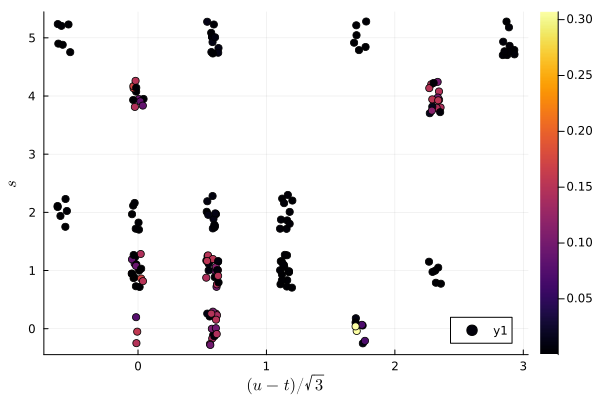

In [26]:
# u_data["coefficient_values"][2]

using Plots
using LaTeXStrings

order = 2
x = []
y = []
z = [] 
for i in eachindex(if shared_data["coefficient_labels"][order] !== nothing shared_data["coefficient_labels"][order] else [] end)
    # k1 + k2 -> k1' + k2'
    s = sum(abs2, (collect((shared_data["coefficient_labels"][2][i][1][1] +  shared_data["coefficient_labels"][2][i][2][1]).coordinates) .- 2) .% dim ) # (k1 + k2)^2
    t = sum(abs2, (shared_data["coefficient_labels"][2][i][1][1] -  shared_data["coefficient_labels"][2][i][1+order][1]).coordinates) # (k1 - k1')^2
    u = sum(abs2, (shared_data["coefficient_labels"][2][i][1][1] -  shared_data["coefficient_labels"][2][i][2+order][1]).coordinates) # (k1 - k2')^2
    # println("($s, $t, $u): $(u_data["coefficient_values"][2][i])")

    push!(x, (u -t)/sqrt(3)+(rand()*2-1)*0.05)
    push!(y, s+(rand()*2-1)*0.3)
    push!(z, coefficient_data[20][i])
end

scatter(x,y,marker_z=abs.(z), xlabel=L"(u - t)/\sqrt{3}", ylabel=L"s")
# plot(x,y)
# 

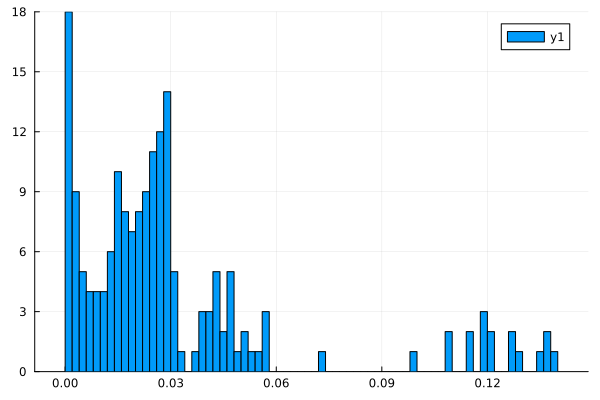

In [47]:
histogram(abs.(z), bins=100)

In [18]:
shared_data["coefficient_labels"][2][1][1][1]

Coordinate(2, 1)